# Digit Classification - Neural Networks: Multiclass and Binary Tasks

Используя наборы данных с цифрами:

а) небольшой встроенный набор
X, y = datasets.load_digits(return_X_y=True)

б) MNIST:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

Демонстрация:
1) Обучение и работа многоклассовой классификации
2) Бинарной классификации на чётные и нечётные цифры
3) Бинарной классификации на '0' и остальные цифры

## Импорт библиотек


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [ ]:
digits = datasets.load_digits()
print(digits.DESCR)  # описание датасета

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

.. _digits_dataset:

Набор данных для оптического распознавания рукописных цифр

**Характеристики набора данных:**

:Количество экземпляров: 1797
:Количество атрибутов: 64
:Информация об атрибутах: изображение размером 8x8 целых пикселей в диапазоне 0..16.
:Отсутствующие значения атрибутов: Отсутствуют
:Автор: Э. Алпайдин (alpaydin '@' boun.edu.tr)
:Дата: июль 1998 г.

Это копия тестового набора наборов рукописных цифр UCI ML.
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

Набор данных содержит изображения написанных от руки цифр: 10 классов, где
каждый класс относится к определенной цифре.

Программы предварительной обработки, доступные в NIST, использовались для извлечения
нормализованных растровых изображений написанных от руки цифр из предварительно напечатанной формы. Из
общего числа 43 человек 30 приняли участие в тренировочном наборе и 13
- в тестовом. Растровые изображения размером 32х32 разбиты на неперекрывающиеся блоки размером
4х4, и в каждом блоке подсчитывается количество пикселей. Это генерирует
входную матрицу размером 8x8, где каждый элемент является целым числом в диапазоне
0..16. Это уменьшает размерность и обеспечивает инвариантность для небольших
искажения.

Для получения информации о процедурах предварительной обработки NIST обратитесь к М. Д. Гаррису, Дж. Л. Блю, Г.
Т. Канделе, Д. Л. Диммику, Дж. Гейсту, П. Дж. Гротеру, С. А. Джанет и К.
Л. Уилсон, Система распознавания отпечатков рук на основе форм NIST, NISTIR 5469,
1994.

.. список использованной литературы

  - С. Кайнак (1995) Методы объединения нескольких классификаторов и их
    Приложения для распознавания рукописных цифр, магистерская диссертация, Институт
    Аспирантуры в области науки и техники, Университет Богазичи.
  - Э. Алпайдин, К. Кайнак (1998) Каскадные классификаторы, Кибернетика.
  - Кен Тан и Поннутурай, Н. Сугантан, Си Яо и А. Кай Цинь.
    Линейное уменьшение размерности с использованием LDA, взвешенного по релевантности. Школа
    Наньянский технологический университет электротехники и электроники.
    2005.
  - Клаудио Джентиле. Новая приблизительная классификация максимальной маржи
    Алгоритм. ЩИПЛЕТ. 2000.

## Первый набор Digits

### 1. Многоклассовая классификация

#### Загрузка датасета

In [ ]:
X, y = datasets.load_digits(return_X_y=True)

In [ ]:
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [ ]:
X.shape

(1797, 64)

In [ ]:
y.shape

(1797,)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Нормализация данных

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Обучение модели

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=42)

In [ ]:
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9833333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      1.00      1.00        46
           5       0.94      0.96      0.95        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.97      0.97      0.97        40

    accuracy                           0.98       360
   macro avg       0.99      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



Модель нейросети (MLP) достигла высокой точности — **98%** на тестовой выборке.  
Ошибки минимальны и распределены равномерно по классам. Наиболее сложными оказались цифры **5** и **9**, где наблюдается небольшое снижение precision/recall.  
В целом, классификатор успешно справляется с многоклассовой задачей.

#### Матрица ошибок

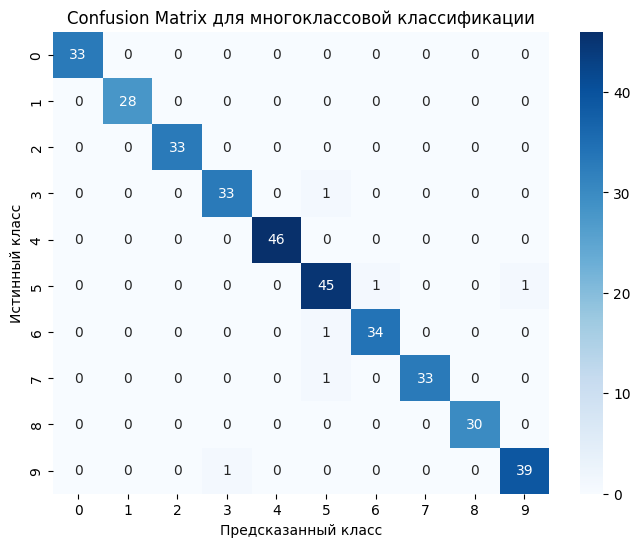

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.title("Confusion Matrix для многоклассовой классификации")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

#### Визуализация ошибок

Ошибок: 6


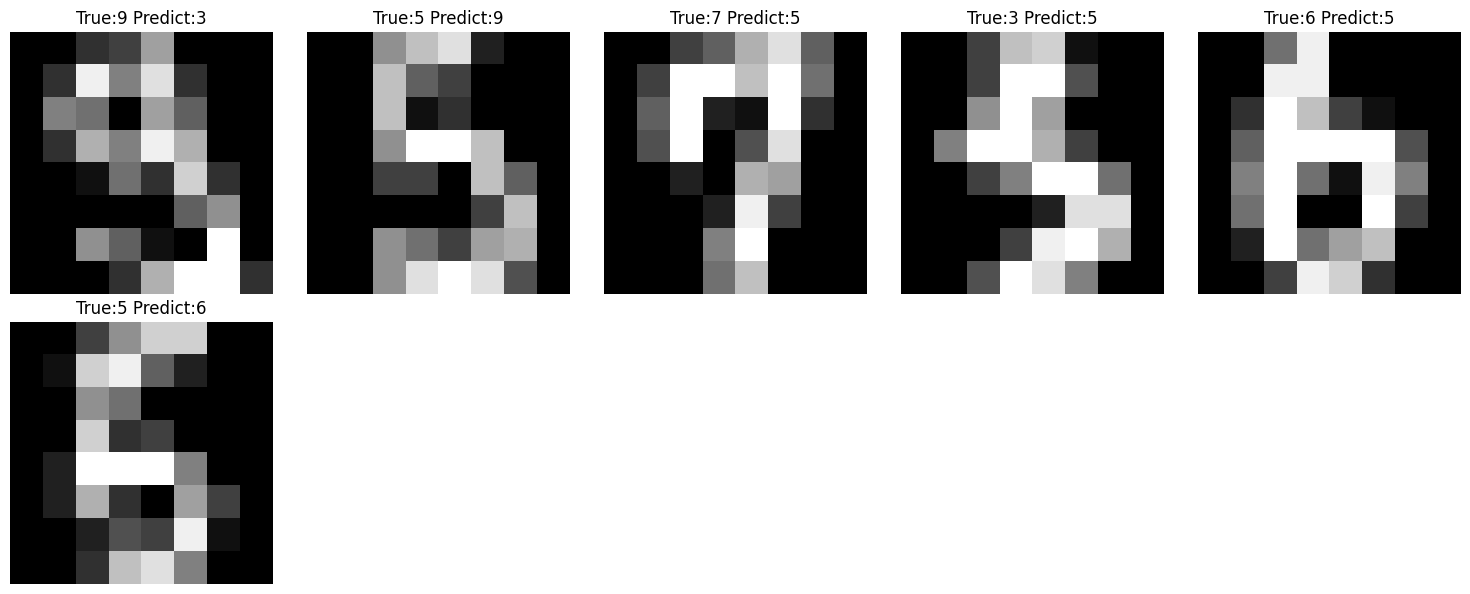

In [ ]:
wrong = np.where(y_pred != y_test)[0]
print(f'Ошибок: {wrong.size}')

cols = 5
rows = int(np.ceil(wrong.size / cols))

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(wrong.size):
    idx = wrong[i]
    image = X_test[idx].reshape(8, 8)
    true_label = y_test[idx]
    pred_label = y_pred[idx]

    plt.subplot(rows, cols, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True:{true_label} Predict:{pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### 2. Бинарная классификация

#### Загрузка датасета

In [ ]:
X, y = datasets.load_digits(return_X_y=True)

In [ ]:
y = (y % 2 == 0).astype(int) # Разделение на чётные/нечётные

0 → нечётная цифра (**odd**)

1 → чётная цифра (**even**)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Нормализация данных

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Обучение модели

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=42)

In [ ]:
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Odd", "Even"]))

Accuracy: 0.9944444444444445
              precision    recall  f1-score   support

         Odd       1.00      0.99      0.99       183
        Even       0.99      1.00      0.99       177

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



Модель классифицирует данные с высокой точностью — 99.4%. Ошибки минимальны: чётные числа определяются без пропусков, а нечётные почти без ложных срабатываний.

#### Матрица ошибок

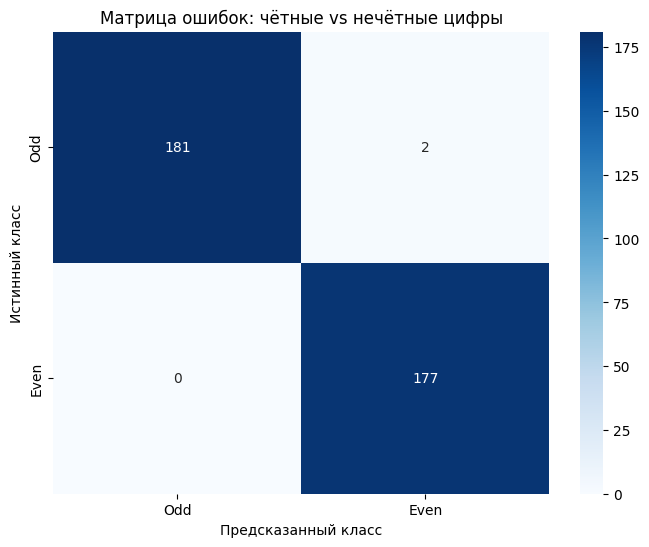

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues',
            xticklabels=["Odd", "Even"],
            yticklabels=["Odd", "Even"])
plt.title("Матрица ошибок: чётные vs нечётные цифры")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

#### Визуализация ошибок

Ошибок: 2


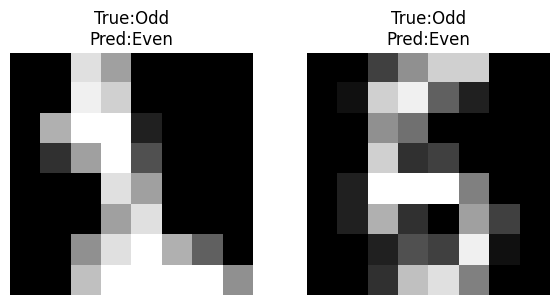

In [ ]:
wrong = np.where(y_pred != y_test)[0]
print(f'Ошибок: {wrong.size}')

cols = 5
rows = int(np.ceil(wrong.size / cols))

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(wrong.size):
    idx = wrong[i]
    image = X_test[idx].reshape(8, 8)

    # Показываем исходные метки цифр (не бинарные)
    true_digit = y[y_test.index[idx]] if hasattr(y_test, 'index') else y[y_test.tolist().index(y_test[idx])]
    true_digit = "Even" if true_digit == 1 else "Odd"

    pred_digit_bin = y_pred[idx]
    pred_digit_text = "Even" if pred_digit_bin == 1 else "Odd"

    plt.subplot(rows, cols, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True:{true_digit}\nPred:{pred_digit_text}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### 3. Бинарная классификация на "0" и остальные цифры

#### Загрузка датасета

In [ ]:
X, y = datasets.load_digits(return_X_y=True)

In [ ]:
y = (y == 0).astype(int) # Разделение на 0 и остальные

0 → 0

1 → остальные цифры

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Нормализация данных

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Обучение модели

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=42)

In [ ]:
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["0", "1-9"]))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       327
         1-9       1.00      1.00      1.00        33

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



Модель классифицирует данные с высокой точностью — 99.4%. Ошибки минимальны: чётные числа определяются без пропусков, а нечётные почти без ложных срабатываний.

#### Матрица ошибок

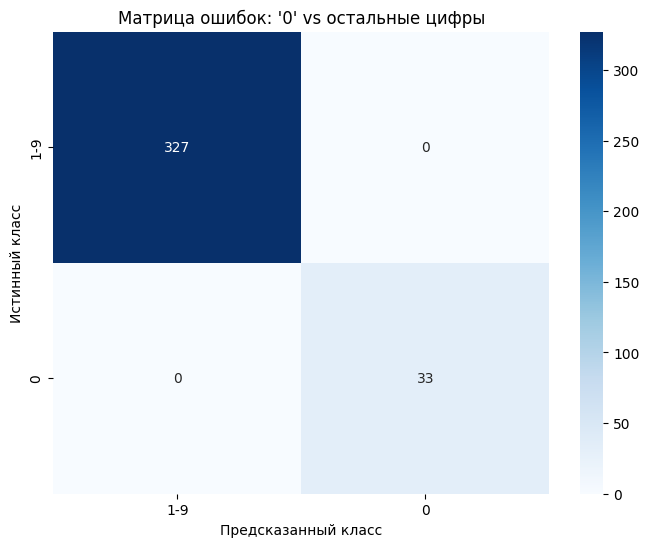

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# Визуализируем матрицу ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues',
            xticklabels=["1-9", "0"],
            yticklabels=["1-9", "0"])
plt.title("Матрица ошибок: '0' vs остальные цифры")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

#### Визуализация ошибок

In [ ]:
wrong = np.where(y_pred != y_test)[0]
print(f'Ошибок: {wrong.size}')

Ошибок: 0


Ошибок нет

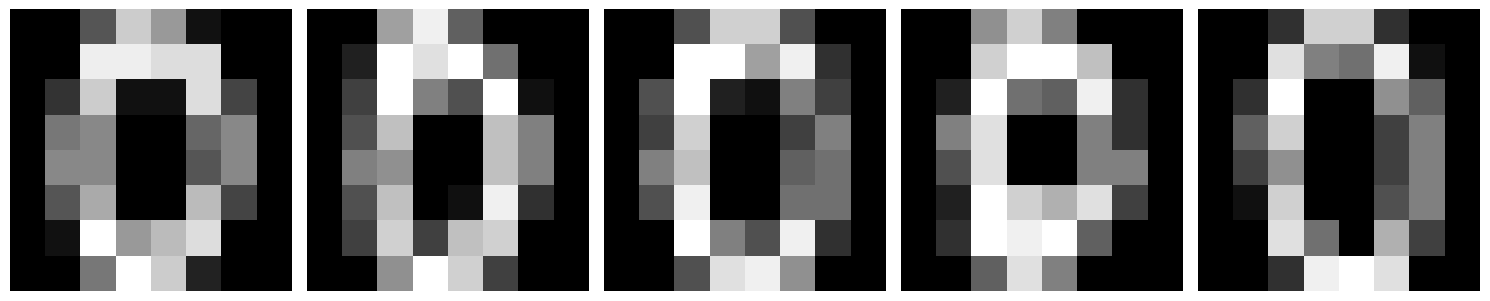

In [ ]:
# Находим индексы, где модель правильно предсказала '0'
correct_zeros = np.where((y_test == 1) & (y_pred == 1))[0]

n_images = min(5, correct_zeros.size)

# Визуализируем 5 картинок
plt.figure(figsize=(15, 8))

for i in range(n_images):
    idx = correct_zeros[i]
    image = X_test[idx].reshape(8, 8)
    plt.subplot(1, n_images, i + 1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

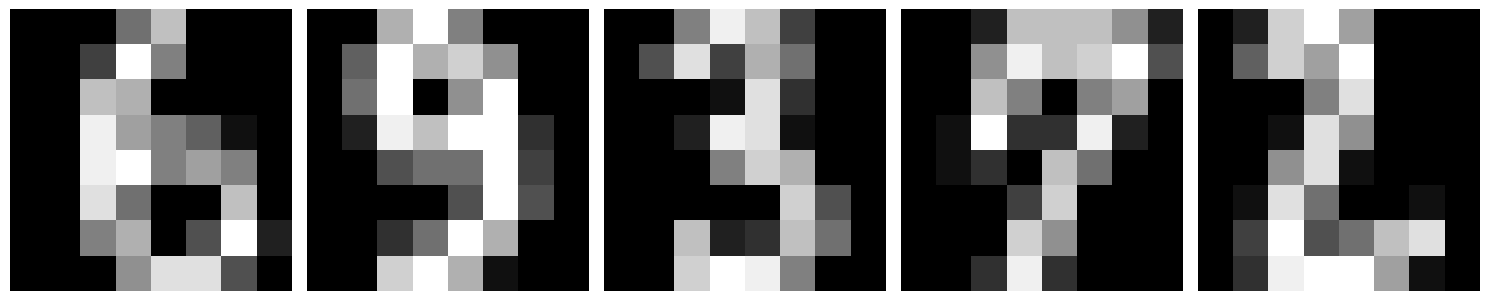

In [ ]:
# Находим индексы, где модель правильно предсказала не '0'
uncorrect_zeros = np.where((y_test == 0) & (y_pred == 0))[0]

n_images = min(5, uncorrect_zeros.size)

# Визуализируем 5 картинок
plt.figure(figsize=(15, 8))

for i in range(n_images):
    idx = uncorrect_zeros[i]
    image = X_test[idx].reshape(8, 8)
    plt.subplot(1, n_images, i + 1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Второй набор MNIST

### 1. Многоклассовая классификация

#### Загрузка датасета

In [ ]:
X, y = datasets.fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

In [ ]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
X.shape

(70000, 784)

In [ ]:
y.shape

(70000,)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Нормализация данных

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Обучение модели

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=20, random_state=42)
mlp.fit(X_train_scaled, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=20, random_state=42)

In [ ]:
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9772142857142857
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.97      0.98      0.97      1380
           3       0.98      0.97      0.98      1433
           4       0.98      0.97      0.97      1295
           5       0.98      0.97      0.98      1273
           6       0.97      0.99      0.98      1396
           7       0.97      0.98      0.98      1503
           8       0.97      0.96      0.97      1357
           9       0.97      0.97      0.97      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



Модель демонстрирует отличные результаты с точностью 97.7%. Все классы (цифры от 0 до 9) классифицируются с высокими значениями precision, recall и f1-score, которые близки к 0.98. Лучшие результаты наблюдаются для цифр «0», «1» и «6», где recall и precision равны 0.99, что указывает на практически идеальную работу модели для этих классов. Немного хуже результаты для цифры «8», где recall составляет 0.96

#### Матрица ошибок

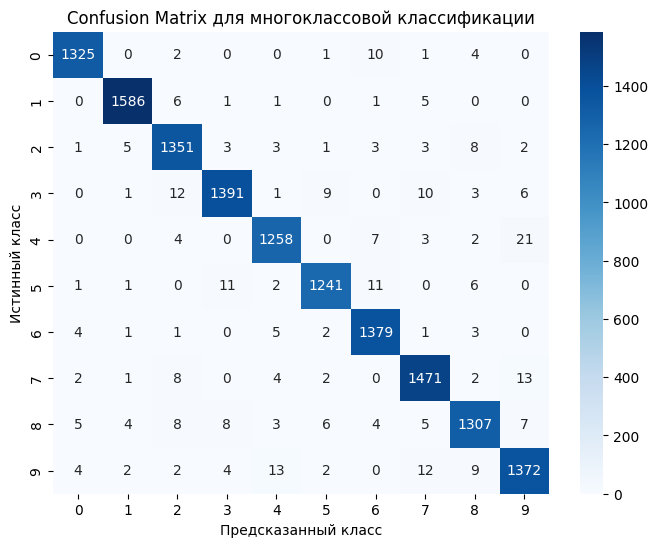

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.title("Confusion Matrix для многоклассовой классификации")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

#### Визуализация ошибок

Ошибок: 319


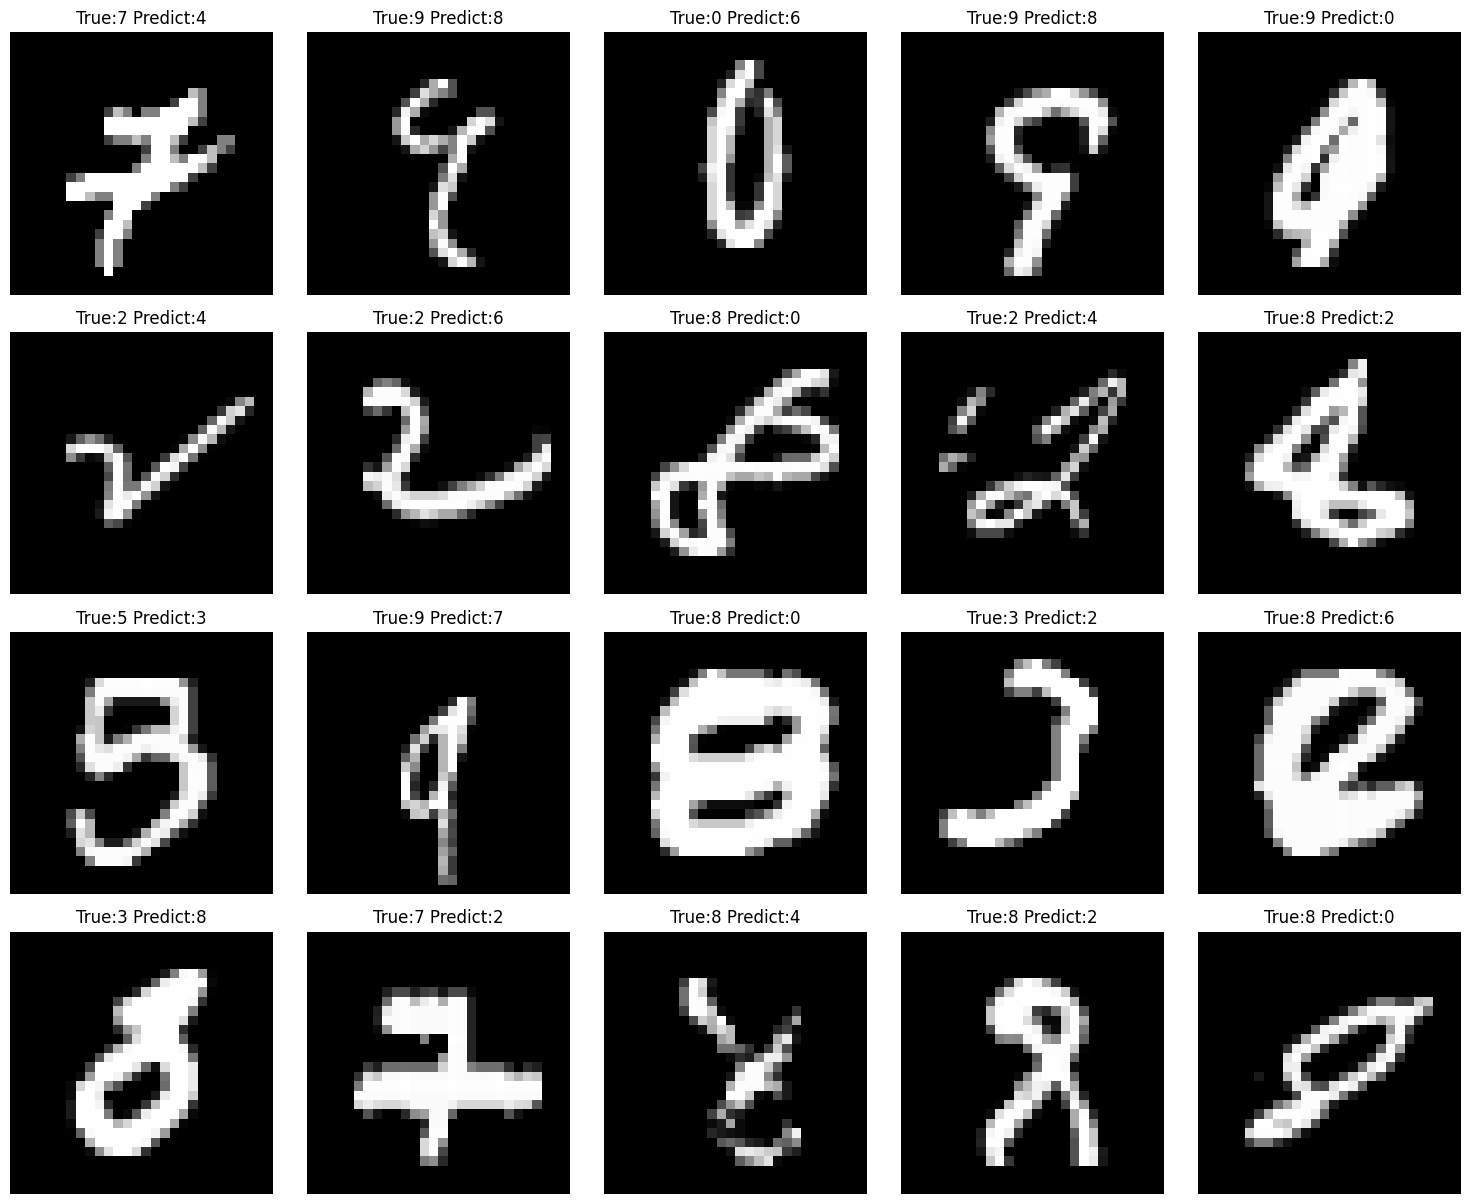

In [ ]:
wrong = np.where(y_pred != y_test)[0]
print(f'Ошибок: {wrong.size}')

cols = 5
rows = int(np.ceil(wrong.size / cols))

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(min(20, wrong.size)):
    idx = wrong[i]
    image = X_test[idx].reshape(28, 28)
    true_label = y_test[idx]
    pred_label = y_pred[idx]

    plt.subplot(rows, cols, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True:{true_label} Predict:{pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### 2. Бинарная классификация

#### Загрузка датасета

In [ ]:
X, y = datasets.fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

In [ ]:
y = y.astype(int)

# Разделение на чётные/нечётные (чётные — 1, нечётные — 0)
y = (y % 2 == 0).astype(int)

0 → нечётная цифра (**odd**)

1 → чётная цифра (**even**)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Нормализация данных

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Обучение модели

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=20, random_state=42)
mlp.fit(X_train_scaled, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=20, random_state=42)

In [ ]:
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Odd", "Even"]))

Accuracy: 0.9852857142857143
              precision    recall  f1-score   support

         Odd       0.99      0.99      0.99      7229
        Even       0.99      0.98      0.98      6771

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



Модель классифицирует данные с высокой точностью — 99.4%. Ошибки минимальны: чётные числа определяются без пропусков, а нечётные почти без ложных срабатываний.

#### Матрица ошибок

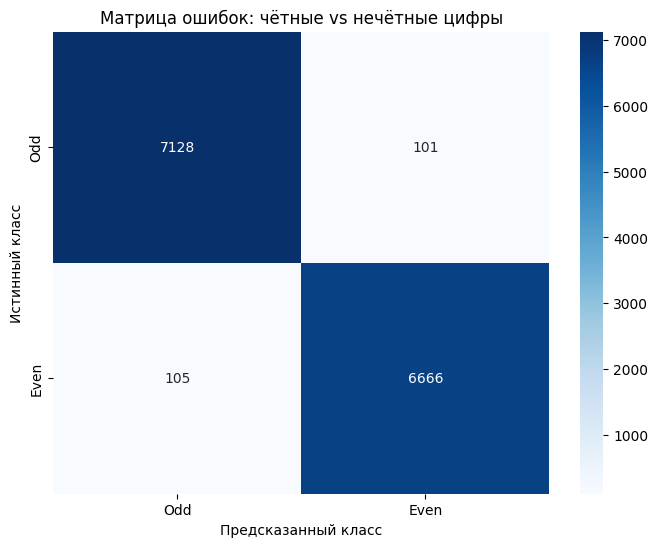

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues',
            xticklabels=["Odd", "Even"],
            yticklabels=["Odd", "Even"])
plt.title("Матрица ошибок: чётные vs нечётные цифры")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

#### Визуализация ошибок

Ошибок: 206


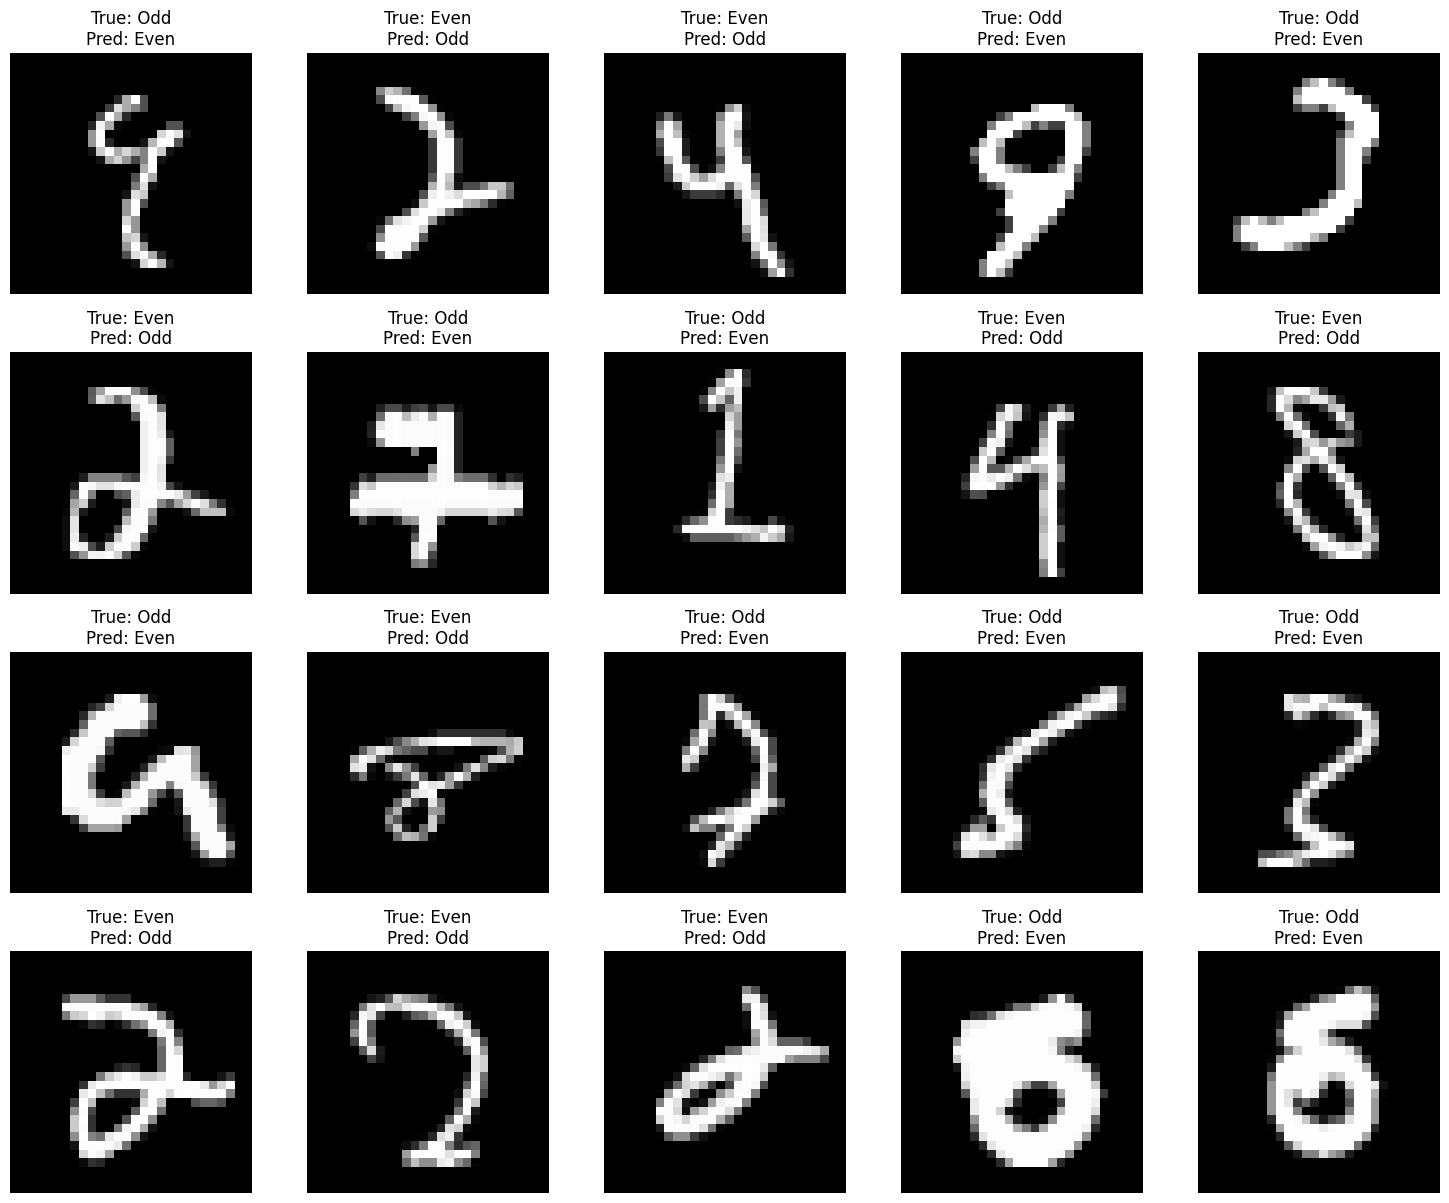

In [ ]:
wrong = np.where(y_pred != y_test)[0]
print(f'Ошибок: {wrong.size}')

cols = 5
rows = int(np.ceil(wrong.size / cols))

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(min(20, wrong.size)):
    idx = wrong[i]
    image = X_test[idx].reshape(28, 28)

    # Используем y_test_raw — оригинальную метку
    true_digit = y_test[idx]
    true_label = "Even" if true_digit % 2 != 0 else "Odd"
    pred_label = "Even" if y_pred[idx] == 1 else "Odd"

    plt.subplot(rows, cols, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

0 → нечётная цифра (odd)

1 → чётная цифра (even)

### 3. Бинарная классификация на "0" и остальные цифры

#### Загрузка датасета

In [ ]:
X, y = datasets.fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

In [ ]:
y = y.astype(int)

y = (y == 0).astype(int) # Разделение на 0 и остальные

0 → 0

1 → остальные цифры

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Нормализация данных

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Обучение модели

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=25, random_state=42)
mlp.fit(X_train_scaled, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=25, random_state=42)

In [ ]:
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["0", "1-9"]))

Accuracy: 0.9973571428571428
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12657
         1-9       0.99      0.98      0.99      1343

    accuracy                           1.00     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       1.00      1.00      1.00     14000



#### Матрица ошибок

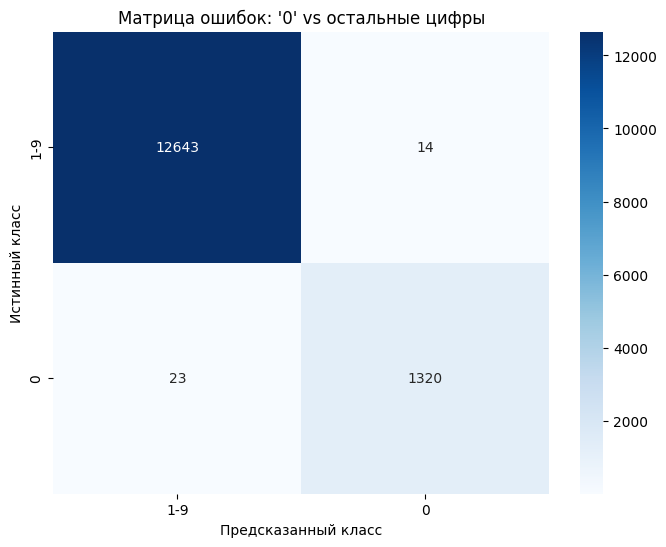

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# Визуализируем матрицу ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues',
            xticklabels=["1-9", "0"],
            yticklabels=["1-9", "0"])
plt.title("Матрица ошибок: '0' vs остальные цифры")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

#### Визуализация ошибок

Ошибок: 37


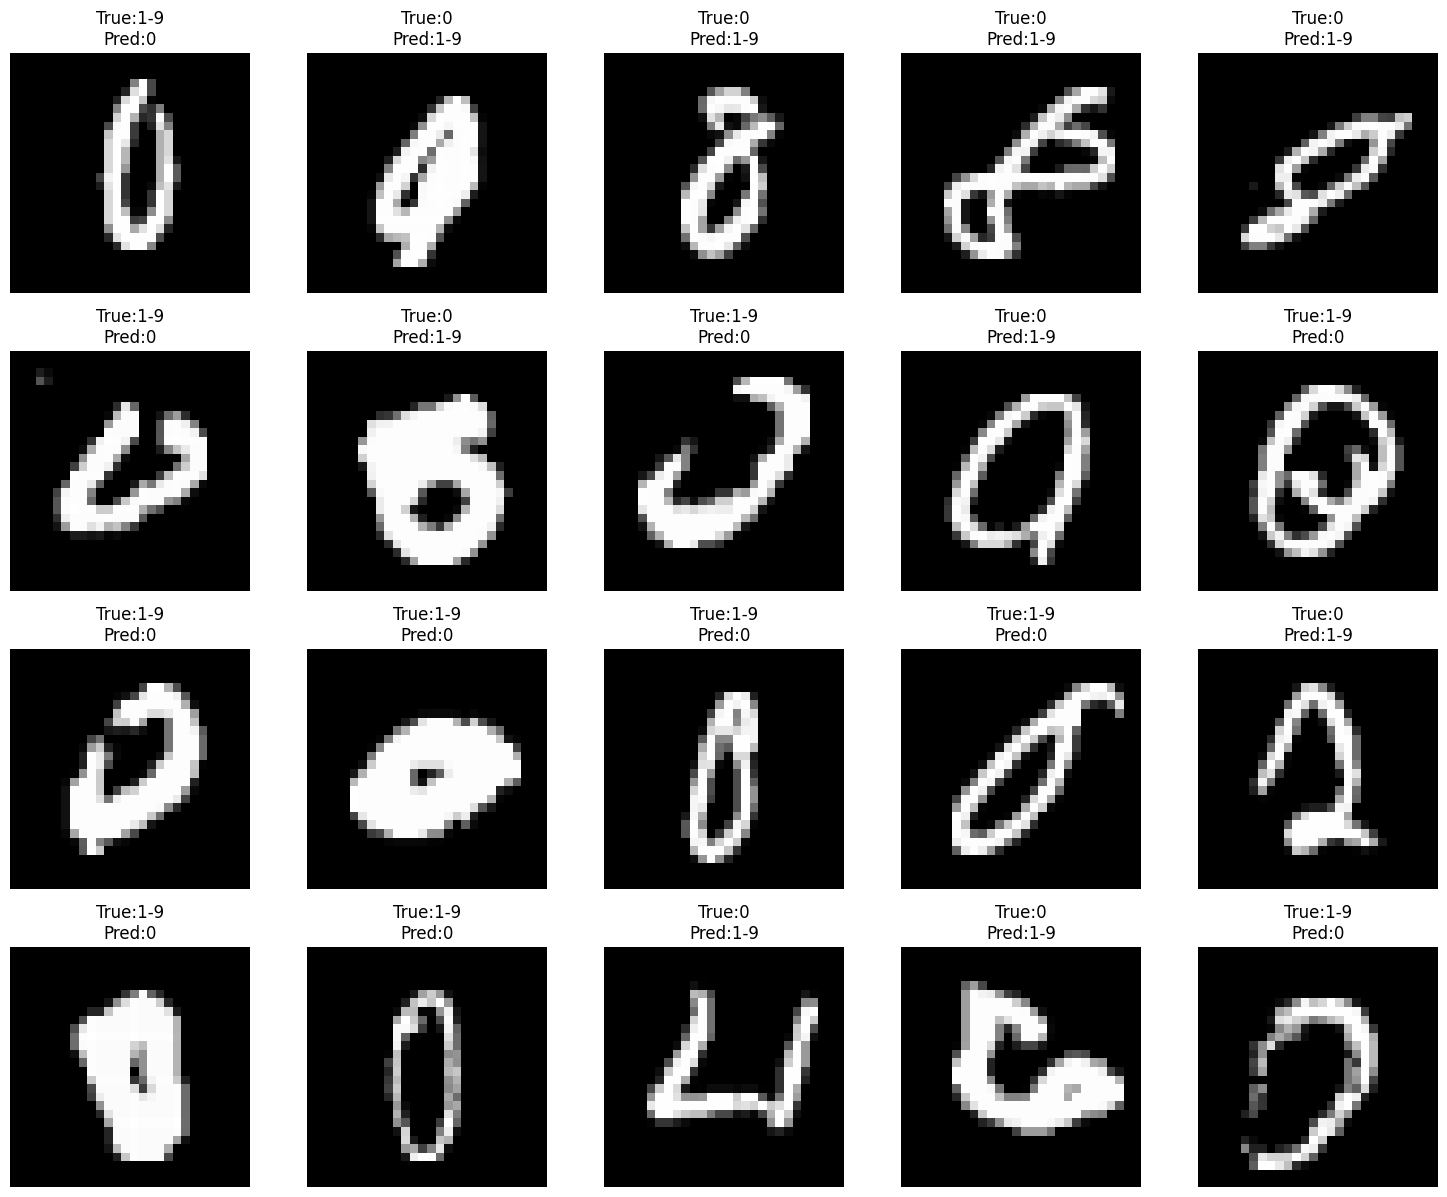

In [ ]:
wrong = np.where(y_pred != y_test)[0]
print(f'Ошибок: {wrong.size}')

cols = 5
rows = int(np.ceil(wrong.size / cols))

plt.figure(figsize=(cols * 3, rows * 3))

for i in range(min(20, wrong.size)):
    idx = wrong[i]
    image = X_test[idx].reshape(28, 28)

    # Показываем исходные метки цифр (не бинарные)
    true_digit = y_test[idx]
    true_digit = "1-9" if true_digit == 1 else "0"
    pred_digit_bin = y_pred[idx]
    pred_digit_text = "1-9" if pred_digit_bin == 1 else "0"

    plt.subplot(rows, cols, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True:{true_digit}\nPred:{pred_digit_text}")
    plt.axis('off')

plt.tight_layout()
plt.show()